<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 166.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 205.0 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 156.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [5]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [6]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [7]:
## Write your code here
print("Number of duplicate rows in dataset:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after dropping duplicates:", df.duplicated().sum())

Number of duplicate rows in dataset: 10
Number of duplicate rows after dropping duplicates: 0


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [8]:
## Write your code here
print("Missing values in Coding Activities column:", df['CodingActivities'].isna().sum())

Missing values in Coding Activities column: 10971


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [9]:
## Write your code here
df['CodingActivities'] = df['CodingActivities'].ffill()
print("Missing values in Coding Activities column after imputing:", df['CodingActivities'].isna().sum())

Missing values in Coding Activities column after imputing: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [10]:
## Write your code here

df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [11]:
print("Missing values in ConvertedCompYearly column:", df['ConvertedCompYearly'].isna().sum())

Missing values in ConvertedCompYearly column: 42002


In [12]:
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())
print("Missing values in the normalized annual compensation column after imputation:",df['ConvertedCompYearly'].isna().sum())

Missing values in the normalized annual compensation column after imputation: 0


##### **Vizualizing raw data distribution before normalizing it:**

The ConvertedCompYearly variable is highly right-skewed, as shown by a mean greater than the median and the presence of very large maximum values. This indicates a long right tail caused by high-income outliers.

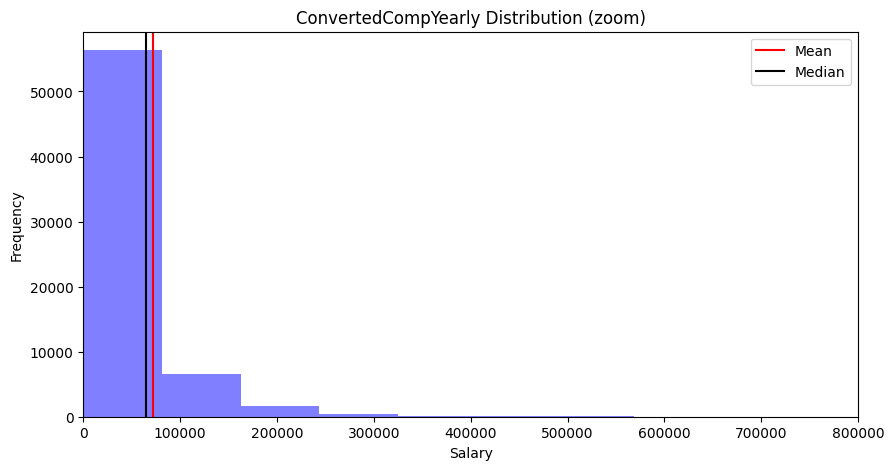

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['ConvertedCompYearly'], bins=200, color='blue', alpha=0.5)

plt.axvline(df['ConvertedCompYearly'].mean(), color='red', label='Mean')
plt.axvline(df['ConvertedCompYearly'].median(), color='black', label='Median')

plt.xlim(0, 800000)

plt.title("ConvertedCompYearly Distribution (zoom)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.legend()

plt.show()

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [14]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 180.7 MB/s eta 0:00:00


In [15]:
## Write your code here

from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
minmax_scaler = MinMaxScaler()

# Create normalized column (0-1 range)
df['ConvertedCompYearly_MinMax'] = minmax_scaler.fit_transform(
    df[['ConvertedCompYearly']]
)

# Quick check
df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,65000.0,0.003998
1,65000.0,0.003998
2,65000.0,0.003998
3,65000.0,0.003998
4,65000.0,0.003998


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [16]:
## Write your code here

from scipy.stats import zscore

# Create Z-score normalized column
df['ConvertedCompYearly_Zscore'] = zscore(
    df['ConvertedCompYearly']
)

# Quick check
df[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head()

,ConvertedCompYearly,ConvertedCompYearly_Zscore
0,65000.0,-0.067514
1,65000.0,-0.067514
2,65000.0,-0.067514
3,65000.0,-0.067514
4,65000.0,-0.067514


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


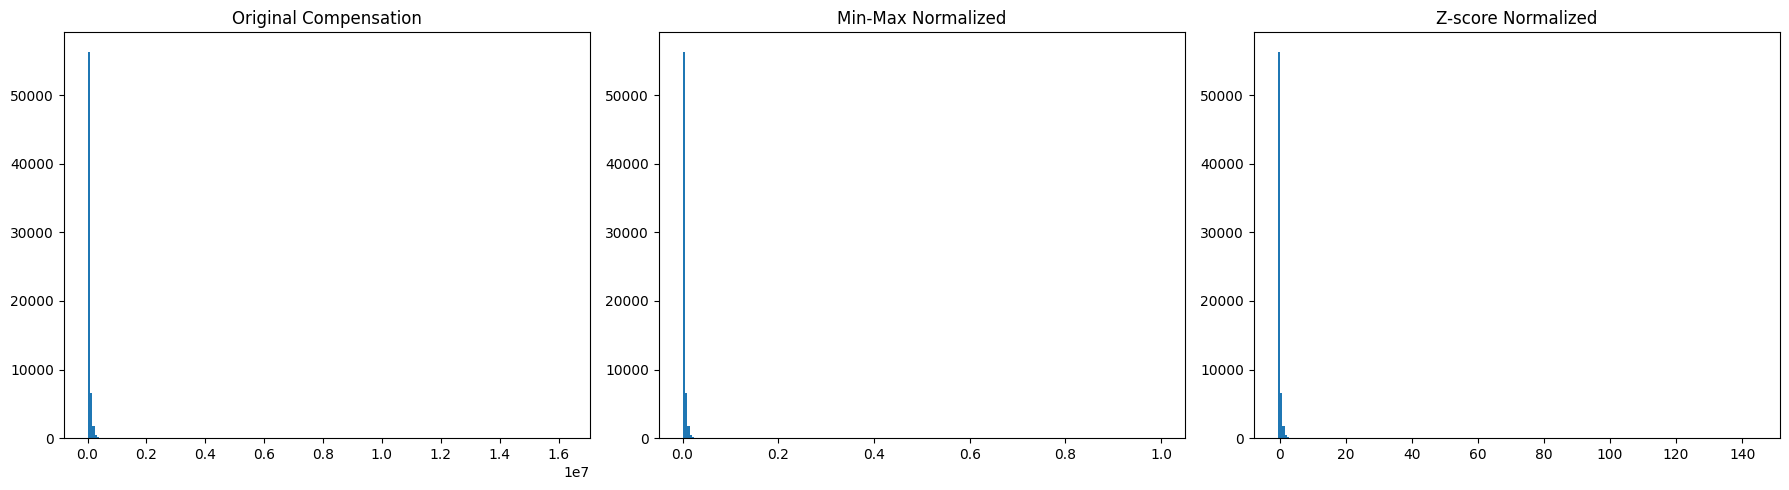

In [45]:
## Write your code here

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Original distribution
ax[0].hist(df['ConvertedCompYearly'], bins=200)
ax[0].set_title('Original Compensation')

# Min-Max normalized distribution
ax[1].hist(df['ConvertedCompYearly_MinMax'], bins=200)
ax[1].set_title('Min-Max Normalized')

# Z-score normalized distribution
ax[2].hist(df['ConvertedCompYearly_Zscore'], bins=200)
ax[2].set_title('Z-score Normalized')

plt.tight_layout()
plt.show()

### **Analysis**

From the plots of Min-Max Normalization and Z-score Normalization for this heavily right-skewed data, none of them showed an improvement. A better transformation for this data would be a logarithmic transformation

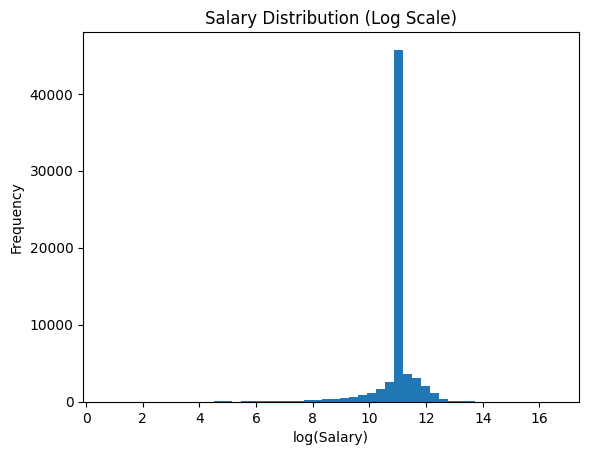

In [49]:
import numpy as np

plt.hist(np.log1p(df['ConvertedCompYearly']), bins=50)
plt.title("Salary Distribution (Log Scale)")
plt.xlabel("log(Salary)")
plt.ylabel("Frequency")
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
